# Assignment 09: Training a Convolutional NN with ChatGPT

#### ⚠ <span style="color:red">**Please read the instructions and doc strings carefully, they are designed to help you!**</span> ⚠

## Submission Info

- Implement your solution by completing the code below
- Locations are marked with `# YOUR CODE HERE` and `raise NotImplementedError()`
- You will score points for providing a correct implementation / solution
- Exercises can be solved with given imports. Usage of standard Python libraries is allowed, but installing any additional packages or external dependencies is prohibited and will result in failing the exercise. If in doubt, don't use additional imports.
- Rename the file according to `<matriculation-number>_<assignment-number>_<filename>.ipynb` (e.g. for student with matriculation number 123456 for assignment 1 and filename intro.ipynb: `123456_1_intro.ipynb`)
- Submit the corresponding Jupyter notebook file to ILIAS

### Additional information for this assignment
- Surprise! In this programming part, you are allowed to <span style="color:green">freely use AI tools</span> for coding, like ChatGPT (https://chat.openai.com/). And for some of you, it may be the first time to get familiar to a new library, pytorch, which is commonly used in the area of Machine Learning. Therefore, we strongly recommend you to ask the AI tool to first understand those functions, especially dimensions and types of inputs and outputs.
- Besides, we kindly remind you that the direct coding results from ChatGPT might not be correct so please check it twice to debug it.
- There might be more empty cells to fill than usual. However, please don't worry since most of them follow exactly the same structure which appears previously and you can simply copy and test them.
- In this project, training some networks on a CPU may potentially take up a significant amount of your time. Therefore, if any devices with gpu or mps are not accessible to you, we recommend running this notebook on Google Colab (https://colab.research.google.com). Upload this notebook, click *change runtime type* in the upper-right hidden menu, and select *T4-GPU* as the hardware accelerator. You can also refer to ChatGPT for more detailed guidance.
- LAST BUT NOT LEAST, <span style="color:red">please report what you prompted in any AI tools</span> if you ask them for assistance.

## Setting up the coding environment

For all coding exercises, we use Python 3. Create a virtual environment and install the libraries specified in the requirements via ```python3 -m pip install -r requirements.txt```.

This time you need to install pytorch and related packages in your virtual environment. Here on the official website (https://pytorch.org/get-started/locally/), you can select your preferences and the corresponding installation commands. If you have cuda devices on your pc and laptop, we suggest installing the cuda version of it to accelerate the training. If you are using Apple products with Apple silicon or AMD GPUS, please refer to this website (https://developer.apple.com/metal/pytorch/) for more information. If you cannot correctly install packages, please also try Google Colab (https://colab.research.google.com).

Now start the notebook and select the correct python kernel (the environment) and make sure that the imports run without error. The following imports should not throw any errors:

---
<span style="color:red">Please also include your name and matriculation number here:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

import numpy as np
import random


Please notice that if you have *mps* device on your Macbook, set the flag below to be **True**. Otherwise, *cuda* device will be tried to find.

In [2]:
## IMPORTANT TO SET: MPS FLAG
use_mps = True

## Load the dataset

In this task, your goal is to implement a convolutional neural network for multi-class classification problem. Our dataset is *Fashion MNIST*, which is a set of 28x28 grayscale images of clothes.

In [3]:
def set_seed_(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if use_mps:
        if torch.backends.mps.is_available():
            torch.mps.manual_seed(seed)
    else:
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

seed = 42
set_seed_(seed)

In the dataloading part, I briefly prompted as follows:

<table><tr><td bgcolor=grey>
"I would like to implement a CNN using PyTorch for a classification problem. I will use the Fashion MNIST dataset. Please generate the data loading part for the training and test datasets, and split 20% of the data out as the validation dataset."
</td></tr></table>

And ChatGPT generated this snippet of code and its corresponding comments for me.

In [4]:
# Transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

# Split the training set into training and validation sets
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size])


# Create data loaders for the training, validation, and test sets
trainloader = DataLoader(train_subset, batch_size=64, shuffle=True)
valloader = DataLoader(val_subset, batch_size=64, shuffle=False)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [5]:
label_map = {0 : "T-shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
          5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}

## Define a CNN
In this section, you should firstly interpret each function (potentially with the aid of ChatGPT) and build up a baseline solution to the problem.

#### <span style="color:red">[TODO]</span> Construct the neural network (4 pts)
Please complete the function  ```create_conv_layers()``` and  ```create_fc_layers()``` according to the image of its architecture. You may need to manually calculate the input and output sizes for some layers. (each 2 pts)

<div align=center><img src="./image1.png" alt="img" width="200">


In [6]:
def create_conv_layers():
    """
    return: an object of class torch.nn.Sequential
    """
    ###BEGIN SOLUTION
    layers = nn.Sequential(
        nn.Conv2d(1, 32, 3, 1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        
        nn.Conv2d(32, 64, 3, 1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3, 1),
        nn.ReLU(),
        )
    ###END SOLUTION
    return layers    

In [7]:
def create_fc_layers():
    """
    return: an object of class torch.nn.Sequential
    """
    ###BEGIN SOLUTION
    layers = nn.Sequential(
        nn.Linear(1152, 128),
        nn.ReLU(),
        
        nn.Linear(128, 10),
        )
    ###END SOLUTION
    return layers    

#### <span style="color:red">[TODO]</span> Identify a bug in ```FashionMNIST_NN``` (2 pts)
In ```FashionMNIST_NN```, here is a hidden bug which only exists on one line. Please identify and modify it by learning how ```nn.CrossEntropyLoss()``` is implemented for classification problem.


In [8]:
## After identifying the bug in this block, please don't modify it anymore for any further questions.
class FashionMNIST_NN(nn.Module):
    def __init__(self, conv_layers, fc_layers, hook_func=None):
        super(FashionMNIST_NN, self).__init__()
        self.conv_layers = conv_layers
        self.fc_layers = fc_layers
        if hook_func is not None:
            self.outputs = {}
            self.hooks = []
            self.hook_func = hook_func
            
    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        ###BEGIN SOLUTION
        ## delete x = torch.softmax(x, dim=1)
        ###END SOLUTION
        return x

    def extract_features_(self):
        if hasattr(self, "outputs"):
            return self.outputs
        else:
            return None
        
    def _remove_hooks(self):
        if hasattr(self, "hooks"):
            for hook in self.hooks:
                hook.remove()
            self.hooks = []
        else:
            pass

    def reset_features(self):
        self.outputs = {}

In [9]:
## Please don't modify this block.
class ModelTrainer:
    def __init__(self, model, trainloader, testloader, train_params, valloader=None, hook_func=None):
        self.model = model
        self.trainloader = trainloader
        self.valloader = valloader
        self.testloader = testloader

        self.criterion = nn.CrossEntropyLoss()
        self.learning_rate = train_params["lr"]
        if train_params["optimizer"] == "adam":
            self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        elif train_params["optimizer"] == "sgd":
            self.optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate)
        else:
            raise NotImplementedError()
        self.use_gpu = train_params["use_gpu"]
        if use_mps:
            self.device = torch.device("mps" if (torch.backends.mps.is_available() and self.use_gpu) else "cpu")
        else:
            self.device = torch.device("cuda:0" if (torch.cuda.is_available() and self.use_gpu) else "cpu")
        print("My device is:", self.device)
        self.model.to(self.device)
        self.seed = train_params["seed"]

    def set_seed(self):
        set_seed_(seed)

    def train(self, epochs=10):
        n_epochs = epochs
        train_losses, val_losses, others = [], [], []
        for epoch in range(n_epochs):
            self.model.train()
            if hasattr(self.model, "hook_func"):
                self.model.hook_func(conv_layers=self.model.conv_layers, outputs=self.model.outputs, hooks=self.model.hooks)
            running_loss = 0.0
            for images, labels in self.trainloader:
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                output = self.model(images)
                loss = self.criterion(output, labels)
                loss.backward()
                self.optimizer.step()
                running_loss += loss.item()
            train_losses.append(running_loss / len(trainloader))            
            self.model._remove_hooks()
            
            # Validation loop
            if self.valloader is not None:
                val_loss, other = self.evaluate()
                val_losses.append(val_loss)
                others.append(other)
            print(f'Epoch {epoch+1}, Training Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

        return train_losses, val_losses, others
    
    def predict(self):
        self.model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in self.testloader:
                images, labels = images.to(self.device), labels.to(self.device)
                output = self.model(images)
                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        accuracy = 100 * correct / total
        print(f'Test Accuracy: {accuracy}%')
        return accuracy
    
    def evaluate(self):
        self.model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in self.valloader:
                images, labels = images.to(self.device), labels.to(self.device)
                output = self.model(images)
                loss = self.criterion(output, labels)
                val_loss += loss.item()

        return val_loss / len(valloader), None
    
    def get_features(self):
        return self.model.extract_features_()
          

In [10]:
model_baseline = FashionMNIST_NN(create_conv_layers(),create_fc_layers())

train_params = {
    "lr": 0.001,
    "optimizer": "sgd",
    "use_gpu": True,
    "seed": 42,
}
trainer_baseline = ModelTrainer(model=model_baseline, trainloader=trainloader, testloader=testloader, train_params=train_params, valloader=valloader)
trainer_baseline.set_seed()
train_losses, val_losses,_ = trainer_baseline.train(epochs=15)

My device is: mps
Epoch 1, Training Loss: 2.2876741800308227, Validation Loss: 2.269833629435681
Epoch 2, Training Loss: 2.240136069615682, Validation Loss: 2.194734622823431
Epoch 3, Training Loss: 2.095810257911682, Validation Loss: 1.9549081858168258
Epoch 4, Training Loss: 1.7107948756217957, Validation Loss: 1.4335463611369437
Epoch 5, Training Loss: 1.2017620220979055, Validation Loss: 1.038508061715897
Epoch 6, Training Loss: 0.9389302975336711, Validation Loss: 0.8762599848052288
Epoch 7, Training Loss: 0.8223811674912771, Validation Loss: 0.796562376174521
Epoch 8, Training Loss: 0.7591670159896214, Validation Loss: 0.7458919419887218
Epoch 9, Training Loss: 0.7185878694454829, Validation Loss: 0.7165685971366599
Epoch 10, Training Loss: 0.6882829910119375, Validation Loss: 0.6851477237774971
Epoch 11, Training Loss: 0.6652088754971822, Validation Loss: 0.668154331914922
Epoch 12, Training Loss: 0.6461264461676279, Validation Loss: 0.6488457545638084
Epoch 13, Training Loss: 0

I would like to plot the training loss and validation loss curves on the same image. I describe my requests as follows:

<table><tr><td bgcolor=grey>
In Python, generate a function that can plot a list of curves on the same image. The inputs are a list of curves and their corresponding labels.
</td></tr></table>

After some modifications like customizing the title and axis labels, I get this ```plot_curves``` function.

In [11]:
## Please don't modify this block.
def plot_curves(curves, labels, xlabel='Epochs', ylabel='Loss', title='Training and Validation Loss'):
    for curve, label in zip(curves, labels):
        plt.plot(curve, label=label)
    plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

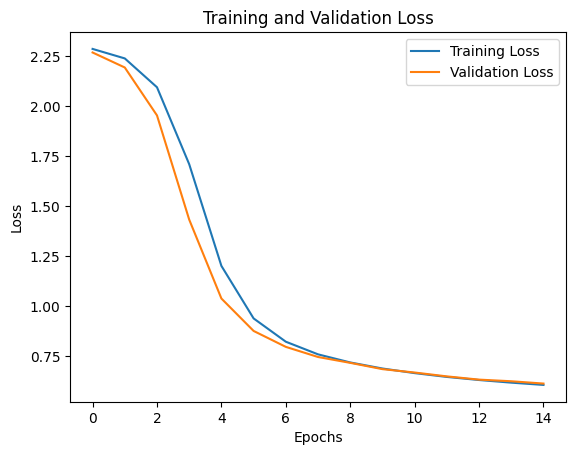

In [12]:
plot_curves([train_losses, val_losses], ["Training Loss", "Validation Loss"])

In [13]:
## EVALUATION
accuracy = trainer_baseline.predict()

Test Accuracy: 77.18%


#### Plot the predicted results
It can be more intuitive for us to visualize the predicted results. We plot images with their corresponding labels and predictions to see if they match.

In [14]:
## Please don't modify this block.
def plot_images(images, labels, preds):
    """
    only plot the first 20 images and 10 images each row
    label_map is defined in a previous cell, which can be directly accessed
    """
    images, labels = images.cpu(), labels.cpu()
    fig = plt.figure(figsize=(25, 4))
    for idx in range(20):
        ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(images[idx]), cmap='gray')
        ax.set_title("{} ({})".format(label_map[preds[idx].item()], label_map[labels[idx].item()]),
                     color=("green" if preds[idx]==labels[idx] else "red"))
    plt.show() 

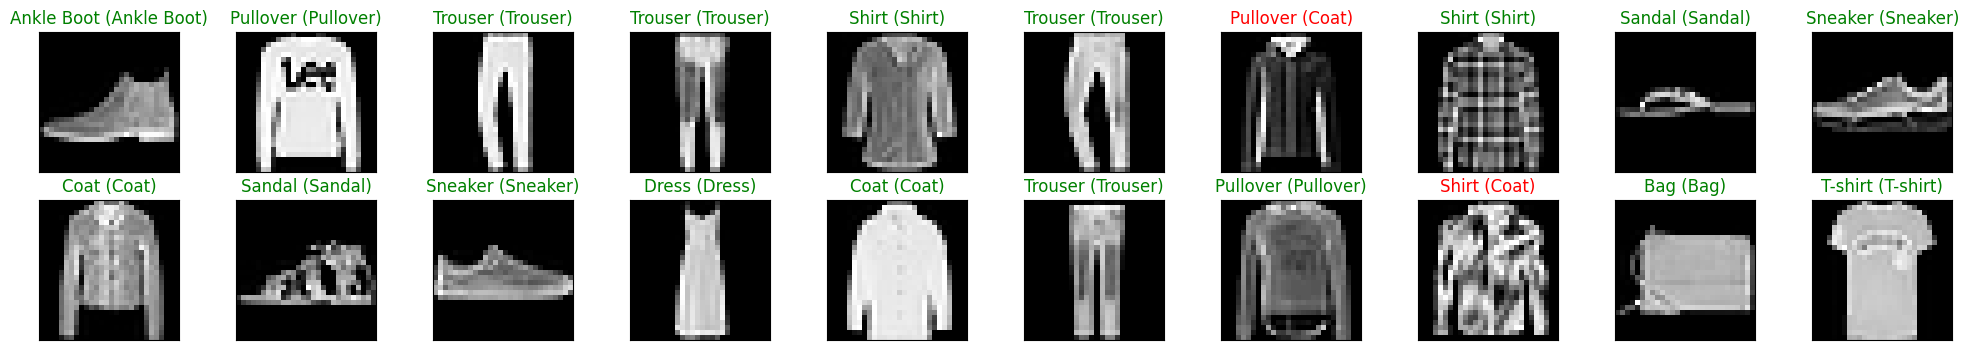

In [15]:
# Get some random test images
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(trainer_baseline.device), labels.to(trainer_baseline.device)

# Predict
output = model_baseline(images)
_, preds = torch.max(output, 1)

plot_images(images, labels, preds)

## Improve the model's performance
In this section, you will explore different tricks utilized in Deep Learning which may be beneficial to improving the model's performance.

#### <span style="color:red">[TODO]</span> Implement BatchNorm (2 pts)
Accordingly, Batch Normalization is said to have some advantages like improving gradient flow, reducing sensitivity to initialization, and preventing overfitting, etc. By simply modifying ```create_conv_layers()``` and ```create_fc_layers()```, you can get the comparison.

In [16]:
def create_conv_layers():
    ###BEGIN SOLUTION
    layers = nn.Sequential(
        nn.Conv2d(1, 32, 3, 1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
        
        nn.Conv2d(32, 64, 3, 1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3, 1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        )
    ###END SOLUTION
    return layers 

def create_fc_layers():
    ###BEGIN SOLUTION
    layers = nn.Sequential(
        nn.Linear(1152, 128),
        nn.ReLU(),
        
        nn.Linear(128, 10),
        )
    ###END SOLUTION
    return layers  

My device is: mps
Epoch 1, Training Loss: 1.6099855399131775, Validation Loss: 1.1081408119582115
Epoch 2, Training Loss: 0.8982401128609975, Validation Loss: 0.7640990963641633
Epoch 3, Training Loss: 0.6920388376315435, Validation Loss: 0.6484867267786188
Epoch 4, Training Loss: 0.6071122486193975, Validation Loss: 0.5851381015270314
Epoch 5, Training Loss: 0.5552850264708201, Validation Loss: 0.5436306738472999
Epoch 6, Training Loss: 0.516834339817365, Validation Loss: 0.5089767922429328
Epoch 7, Training Loss: 0.48516558261712395, Validation Loss: 0.48111807507403354
Epoch 8, Training Loss: 0.45921077934900917, Validation Loss: 0.45656565679831707
Epoch 9, Training Loss: 0.4362264723380407, Validation Loss: 0.4376496987298448
Epoch 10, Training Loss: 0.4162657859722773, Validation Loss: 0.41863110962700334
Epoch 11, Training Loss: 0.39894457894563673, Validation Loss: 0.4039220904257703
Epoch 12, Training Loss: 0.3840159955223401, Validation Loss: 0.3915777349091591
Epoch 13, Trai

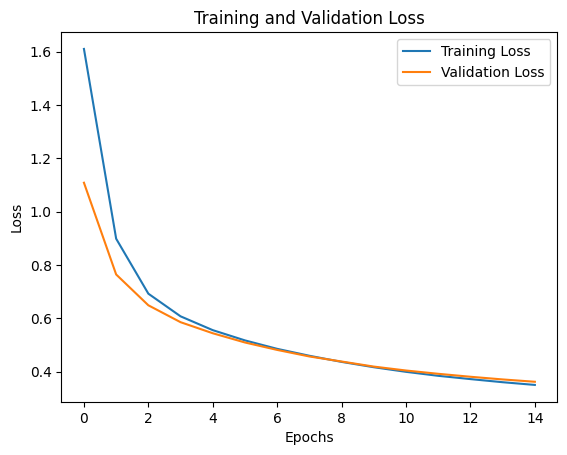

In [17]:
###BEGIN SOLUTION
model_BatchNorm = FashionMNIST_NN(create_conv_layers(),create_fc_layers())

train_params = {
    "lr": 0.001,
    "optimizer": "sgd",
    "use_gpu": True,
    "seed": 42,
}
trainer_BatchNorm = ModelTrainer(model=model_BatchNorm, trainloader=trainloader, testloader=testloader, train_params=train_params, valloader=valloader)
trainer_BatchNorm.set_seed()
train_losses, val_losses,_ = trainer_BatchNorm.train(epochs=15)
###END SOLUTION

plot_curves([train_losses, val_losses], ["Training Loss", "Validation Loss"])

#### <span style="color:red">[TODO]</span> Switch the optimizer (4 pts)
You may realize the baseline is using SGD optimizer. To achieve a better performance, please adjust and report the learning rate for it (without modifying the number of epochs).

In [18]:
###BEGIN SOLUTION
# A reference learning rate is 0.05. (2 pts)

In [19]:
###BEGIN SOLUTION
model_SGD_lr = FashionMNIST_NN(create_conv_layers(),create_fc_layers())

train_params = {
    "lr": 0.05,
    "optimizer": "sgd",
    "use_gpu": True,
    "seed": 42,
}
trainer_SGD_lr = ModelTrainer(model=model_SGD_lr, trainloader=trainloader, testloader=testloader, train_params=train_params, valloader=valloader)
trainer_SGD_lr.set_seed()
train_losses, val_losses,_ = trainer_SGD_lr.train(epochs=15)
###END SOLUTION

My device is: mps
Epoch 1, Training Loss: 0.46233934407432875, Validation Loss: 0.3373984138857811
Epoch 2, Training Loss: 0.2967977680563927, Validation Loss: 0.2916030967806248
Epoch 3, Training Loss: 0.2526879890561104, Validation Loss: 0.30121009555110273
Epoch 4, Training Loss: 0.22245275148749352, Validation Loss: 0.2889039986073337
Epoch 5, Training Loss: 0.19797476972142855, Validation Loss: 0.2728049544260857
Epoch 6, Training Loss: 0.17582086300104857, Validation Loss: 0.2701829443190326
Epoch 7, Training Loss: 0.15748557781179745, Validation Loss: 0.26702335227201596
Epoch 8, Training Loss: 0.13958976579954227, Validation Loss: 0.31525549700761096
Epoch 9, Training Loss: 0.12577646496891975, Validation Loss: 0.282871964407411
Epoch 10, Training Loss: 0.11126968563596408, Validation Loss: 0.2823194540006683
Epoch 11, Training Loss: 0.10146901069084803, Validation Loss: 0.2830515620794068
Epoch 12, Training Loss: 0.08790009169528881, Validation Loss: 0.29416873371426727
Epoch 

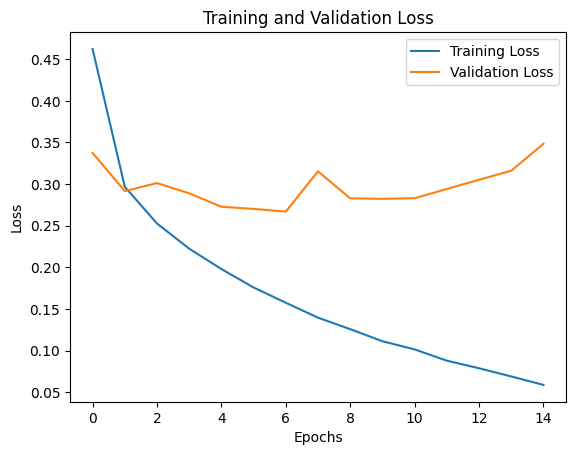

Test Accuracy: 90.64%


In [20]:
###BEGIN SOLUTION
plot_curves([train_losses, val_losses], ["Training Loss", "Validation Loss"])
accuracy = trainer_SGD_lr.predict()
###END SOLUTION

An alternative approach is to switch to Adam optimizer without changing the initial learning rate. Please check the result with Adam optimizer. Please present at least one advantage of utilizing it.

In [21]:
###BEGIN SOLUTION
# Compared with SGD, it requires less parameter tuning. (2 pts)

My device is: mps
Epoch 1, Training Loss: 0.3972149533728758, Validation Loss: 0.30147003818382606
Epoch 2, Training Loss: 0.2696485499838988, Validation Loss: 0.2717618935919823
Epoch 3, Training Loss: 0.22670540120700994, Validation Loss: 0.25368944095804336
Epoch 4, Training Loss: 0.19648091830313205, Validation Loss: 0.25913081333992327
Epoch 5, Training Loss: 0.16878480725487074, Validation Loss: 0.2588699506992038
Epoch 6, Training Loss: 0.14844879878809056, Validation Loss: 0.2524759573069342
Epoch 7, Training Loss: 0.12484176325798034, Validation Loss: 0.2610120737251449
Epoch 8, Training Loss: 0.10940748236204187, Validation Loss: 0.272954867508738
Epoch 9, Training Loss: 0.09124266348655025, Validation Loss: 0.32036653606894805
Epoch 10, Training Loss: 0.08145804749242962, Validation Loss: 0.33161231491001364
Epoch 11, Training Loss: 0.06866222573071719, Validation Loss: 0.3467949258876925
Epoch 12, Training Loss: 0.06131779763599237, Validation Loss: 0.3706384503005191
Epoch

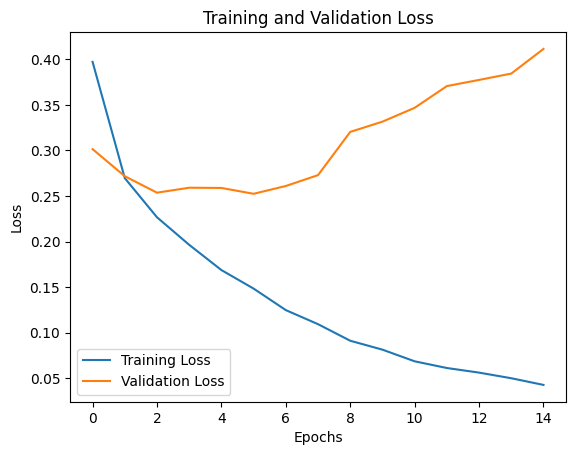

In [22]:
###BEGIN SOLUTION
model_Adam = FashionMNIST_NN(create_conv_layers(),create_fc_layers())

train_params = {
    "lr": 0.001,
    "optimizer": "adam",
    "use_gpu": True,
    "seed": 42,
}
trainer_Adam = ModelTrainer(model=model_Adam, trainloader=trainloader, testloader=testloader, train_params=train_params, valloader=valloader)
trainer_Adam.set_seed()
train_losses, val_losses,_ = trainer_Adam.train(epochs=15)
###END SOLUTION

plot_curves([train_losses, val_losses], ["Training Loss", "Validation Loss"])

#### <span style="color:red">[TODO]</span> Analyse the results (5 pts)
Firstly, please report what you observe from the loss curves from the previous optimizer switch. (1 pt)

In [23]:
###BEGIN SOLUTION
# The problem is Overfitting. (1 pt)
###END SOLUTION

You might also notice that while the test accuracy is good, however, the validation loss is increasingly large. Investigate how the validation accuracy develops thoughout training. Do this by creating a subclass of ```ModelTrainer``` and by modifying the validation function (You can use List *others* to store validation accuracy). (3 pts)

What do you observe? (1 pt)

In [24]:

class NewModelTrainer(ModelTrainer):
    def __init__(self, model, trainloader, testloader, train_params, valloader=None, hook_func=None):
        super().__init__(model, trainloader, testloader, train_params, valloader, hook_func)
    
    def evaluate(self):
        ###BEGIN SOLUTION
        self.model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in self.valloader:
                images, labels = images.to(self.device), labels.to(self.device)
                output = self.model(images)
                loss = self.criterion(output, labels)
                val_loss += loss.item()

                _, predicted = torch.max(output.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f'Validation Accuracy: {accuracy}%')
        return val_loss / len(self.valloader), accuracy 
        ###END SOLUTION

In [25]:
###BEGIN SOLUTION
model_Adam = FashionMNIST_NN(create_conv_layers(),create_fc_layers())

train_params = {
    "lr": 0.001,
    "optimizer": "adam",
    "use_gpu": True,
    "seed": 42,
}
trainer_Adam = NewModelTrainer(model=model_Adam, trainloader=trainloader, testloader=testloader, train_params=train_params, valloader=valloader)
trainer_Adam.set_seed()
train_losses, val_losses, val_accuracy = trainer_Adam.train(epochs=15)
###END SOLUTION

My device is: mps
Validation Accuracy: 89.15833333333333%
Epoch 1, Training Loss: 0.40267942775289217, Validation Loss: 0.304117462736495
Validation Accuracy: 90.325%
Epoch 2, Training Loss: 0.27087326417366664, Validation Loss: 0.26870308063448745
Validation Accuracy: 90.975%
Epoch 3, Training Loss: 0.22806990863879523, Validation Loss: 0.2511786370676883
Validation Accuracy: 90.95%
Epoch 4, Training Loss: 0.19585426353414853, Validation Loss: 0.2547606166769215
Validation Accuracy: 90.83333333333333%
Epoch 5, Training Loss: 0.16921462544302146, Validation Loss: 0.2539225450142267
Validation Accuracy: 91.25833333333334%
Epoch 6, Training Loss: 0.14540689709037544, Validation Loss: 0.2528399201506313
Validation Accuracy: 91.575%
Epoch 7, Training Loss: 0.12566753413776557, Validation Loss: 0.26945088199399253
Validation Accuracy: 91.325%
Epoch 8, Training Loss: 0.10835474006583293, Validation Loss: 0.2805618817838741
Validation Accuracy: 90.99166666666666%
Epoch 9, Training Loss: 0.093

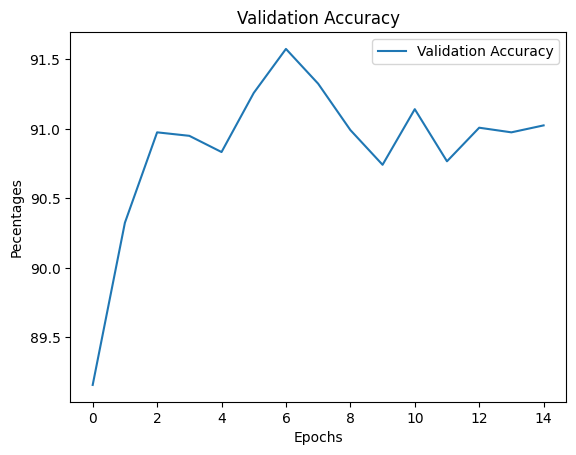

In [26]:
plot_curves([val_accuracy], ["Validation Accuracy"], xlabel='Epochs', ylabel='Pecentages', title='Validation Accuracy')

In [ ]:
###BEGIN SOLUTION
# The validation accuracy is not noticeably dropping down. In terms of the model's performance, validation accuracy might be a better indicator than validation loss.
###END SOLUTION

In [32]:
def view_class_probs(img, ps, truth_label):

    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(img.resize_(1, 28, 28).numpy().squeeze())
    ax1.axis('off')
    ax2.barh(np.arange(10), ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))

    labels = ['T-shirt/top',
                        'Trouser',
                        'Pullover',
                        'Dress',
                        'Coat',
                        'Sandal',
                        'Shirt',
                        'Sneaker',
                        'Bag',
                        'Ankle Boot']
    colors = ['black'] * 10
    colors[truth_label] = 'red'

    ax2.set_yticklabels(labels, size='small')

    for color,tick in zip(colors,ax2.yaxis.get_major_ticks()):
        tick.label1.set_color(color)
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

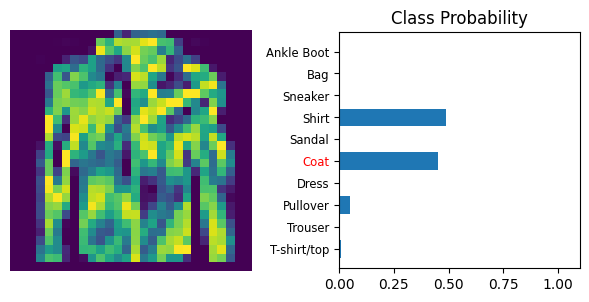

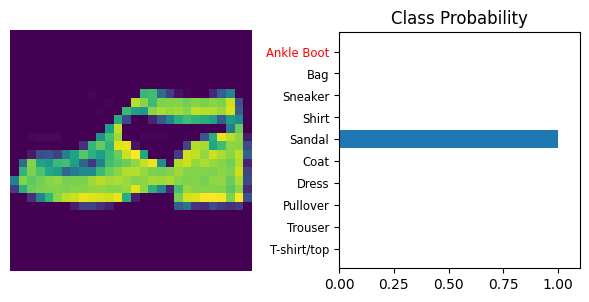

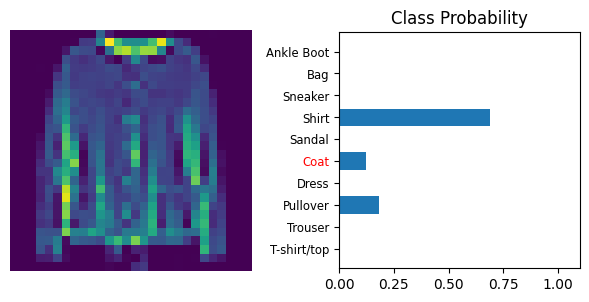

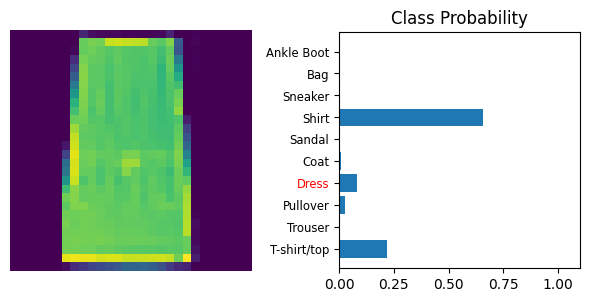

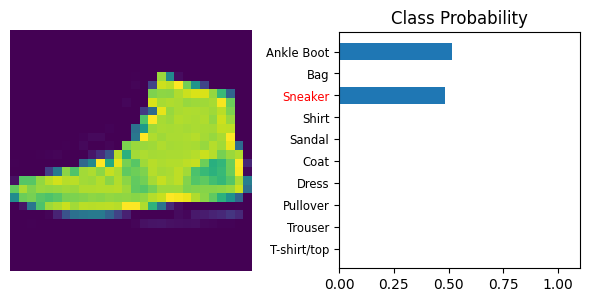

In [33]:
# Get some test images
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(trainer_baseline.device), labels.to(trainer_baseline.device)

# Predict
output = model_baseline(images)
probs = torch.softmax(output, 1)
probs = probs.detach().cpu().numpy()

counts = 0
for i in range(probs.shape[0]):
    if (labels[i].detach().cpu().numpy() != np.argmax(probs[i])) and counts <= 4:
        view_class_probs(images[i].cpu(), probs[i], labels[i].detach().cpu().numpy().item())
        counts +=1

#### <span style="color:red">[TODO]</span> (Bonus) Extract the intermediate features (3 pts)

You may notice that in ```FashionMNIST_NN```, there is a placeholder for a hook function, which can be used to capture the intermediate outputs from convolutional layers. Please Complete this function ```registered_hooks()``` below. Use it to initialize a new model and train it for one more time to visualize the intermediate outputs.

In [34]:
###BEGIN SOLUTION
def registered_hooks(conv_layers, outputs, hooks):
    # Hook function to capture outputs
    def get_activation(name):
        def hook(model, input, output):
            if name not in outputs:
                outputs[name] = []
                outputs[name].append(output.detach().cpu())
        return hook

    for name, layer in conv_layers.named_children():
        if isinstance(layer, torch.nn.modules.conv.Conv2d):
            hook = layer.register_forward_hook(get_activation('conv_{}'.format(name)))
            hooks.append(hook)
###END SOLUTION

In [35]:
###BEGIN SOLUTION
model_hooks = FashionMNIST_NN(create_conv_layers(),create_fc_layers(), hook_func=registered_hooks)

train_params = {
    "lr": 0.001,
    "optimizer": "adam",
    "use_gpu": True,
    "seed": 42,
}
trainer_hooks = ModelTrainer(model=model_hooks, trainloader=trainloader, testloader=testloader, train_params=train_params, valloader=valloader, hook_func=registered_hooks)
trainer_hooks.set_seed()
train_losses, val_losses,_ = trainer_hooks.train(epochs=10)
###END SOLUTION

My device is: mps
Epoch 1, Training Loss: 0.5476536767284076, Validation Loss: 0.3614270733074939
Epoch 2, Training Loss: 0.3877878003716469, Validation Loss: 0.3136756703099038
Epoch 3, Training Loss: 0.35658162383238473, Validation Loss: 0.288847545835566
Epoch 4, Training Loss: 0.3374828000664711, Validation Loss: 0.27639722828059754
Epoch 5, Training Loss: 0.3194275618195534, Validation Loss: 0.27696496957635625
Epoch 6, Training Loss: 0.30812208212415376, Validation Loss: 0.27135548653437735
Epoch 7, Training Loss: 0.29797057242194813, Validation Loss: 0.2594855407134016
Epoch 8, Training Loss: 0.29214339341719947, Validation Loss: 0.2496967742100675
Epoch 9, Training Loss: 0.2834290768802166, Validation Loss: 0.2511986515464935
Epoch 10, Training Loss: 0.2733422773679097, Validation Loss: 0.24198076547064046


In [36]:
## Please don't modify this block.
def plot_feature_maps(feature_maps, n_cols=8):
    n_filters = feature_maps.shape[1]
    n_rows = n_filters // n_cols
    if n_filters % n_cols != 0:
        n_rows += 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        if i < n_filters:
            ax.imshow(feature_maps[0, i].cpu().numpy(), cmap='gray')
        ax.axis('off')
    plt.show()

Visualizing outputs:
The layer conv_0's outputs are:


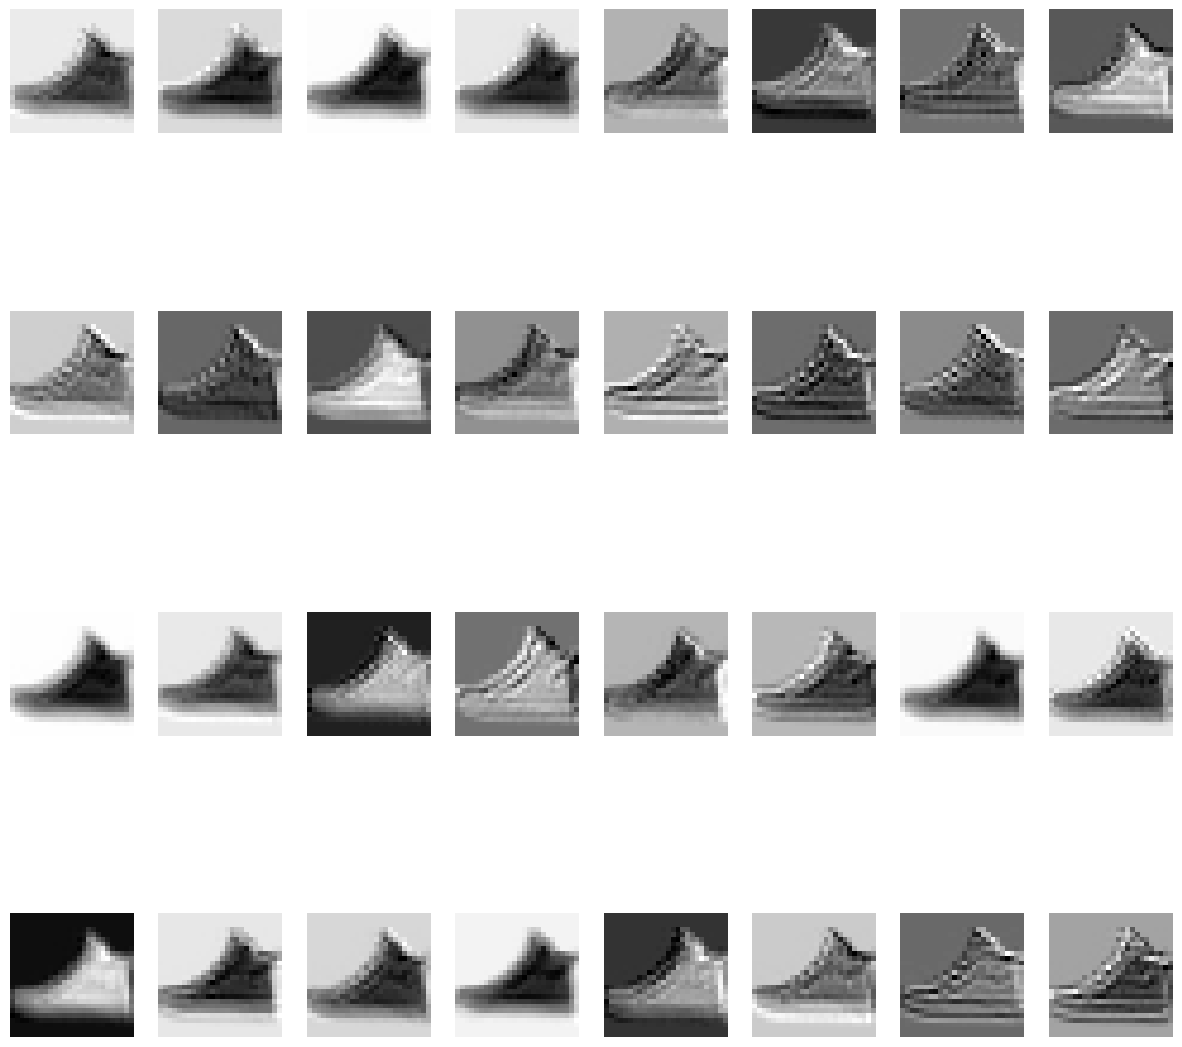

The layer conv_5's outputs are:


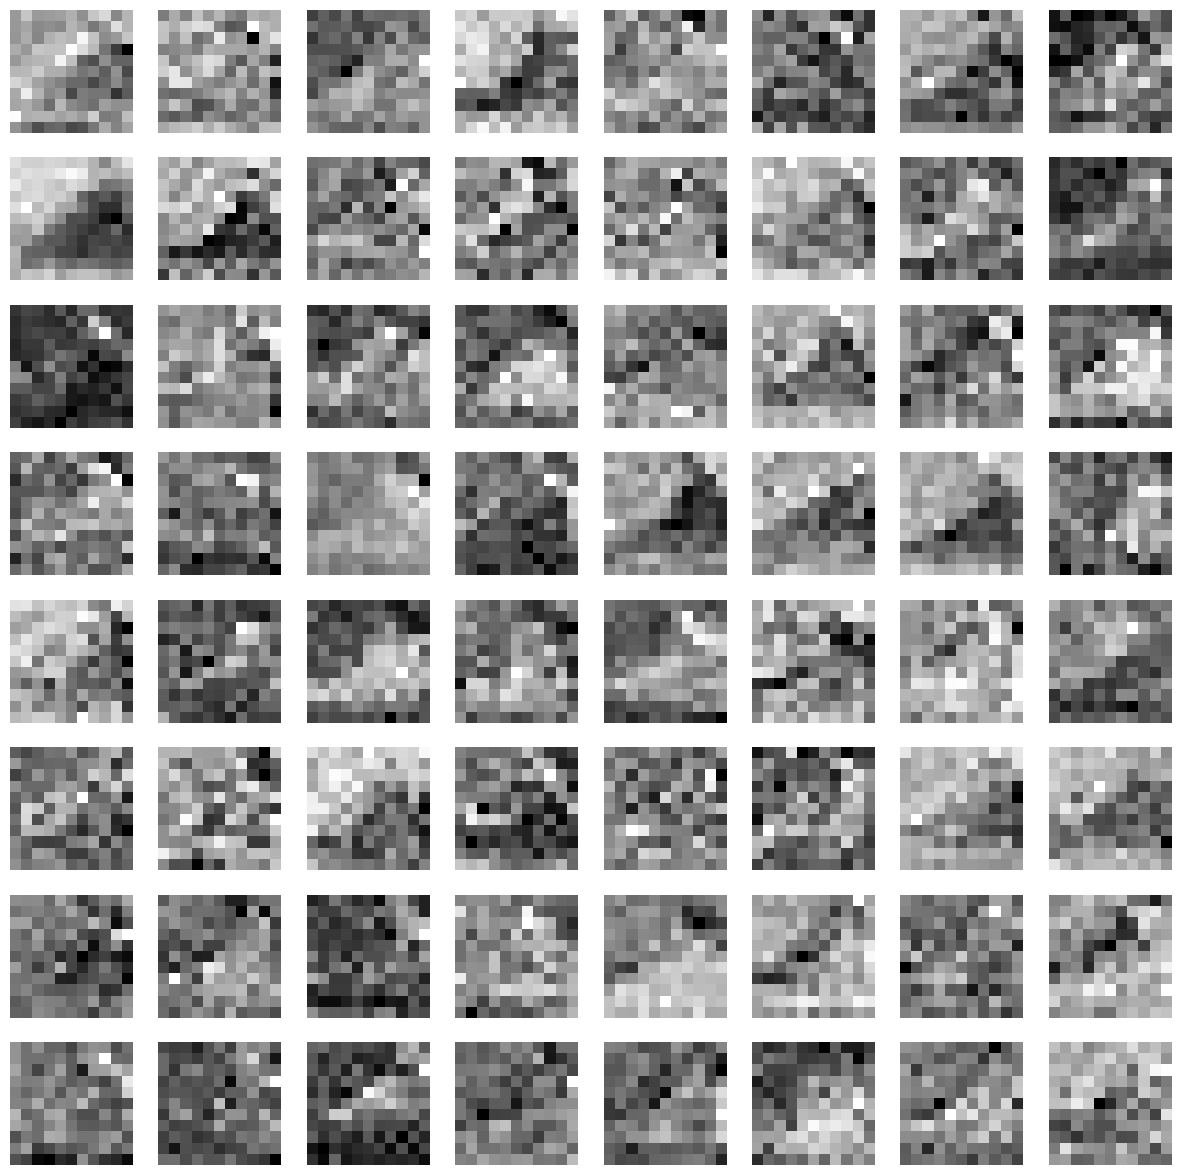

The layer conv_10's outputs are:


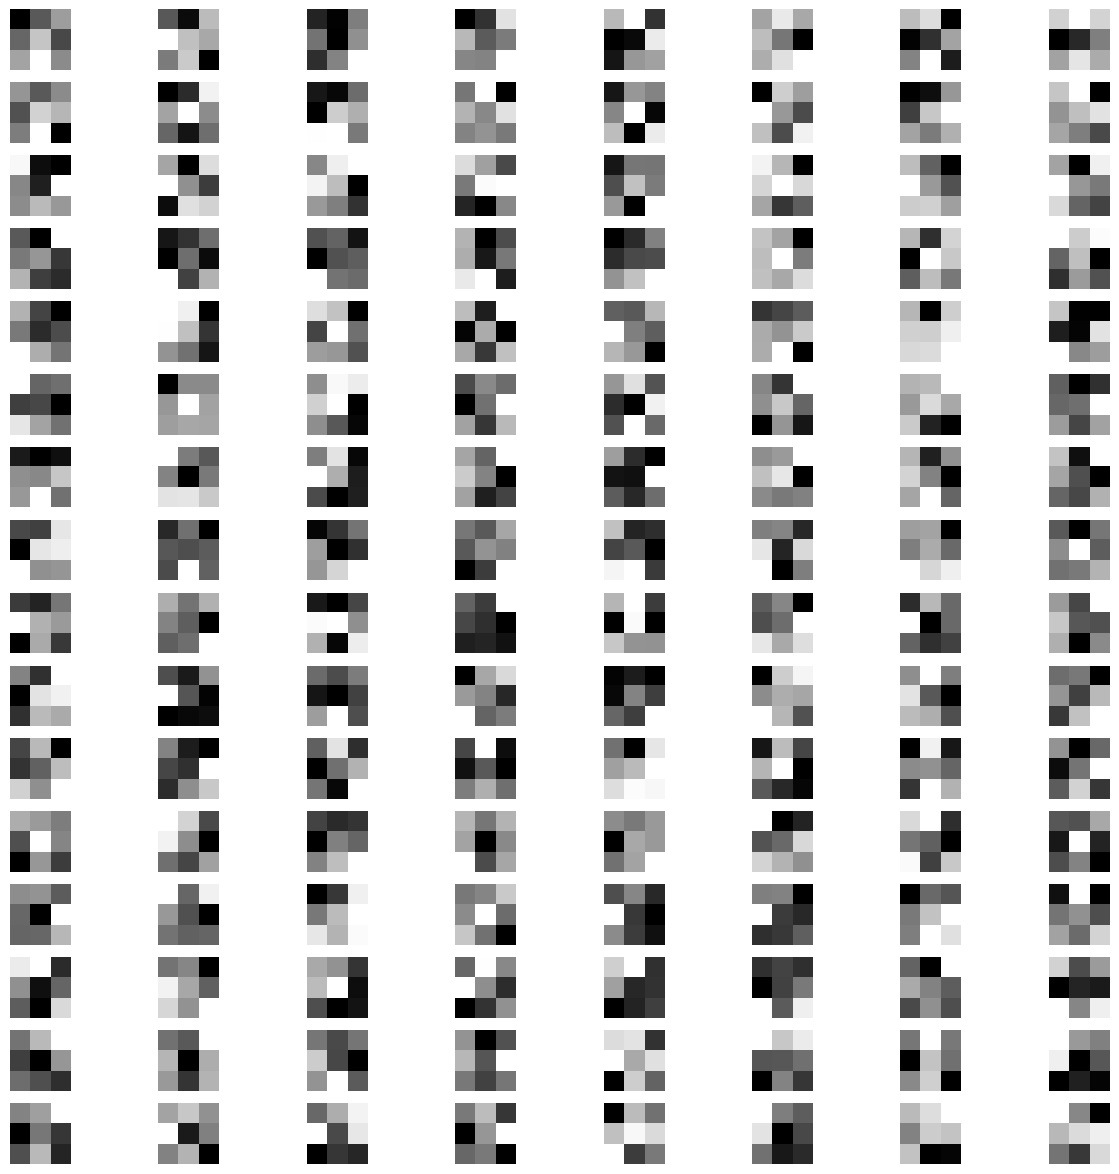

In [37]:
print("Visualizing outputs:")
features = trainer_hooks.get_features()
for k, v in features.items():
    print("The layer {}'s outputs are:".format(k))
    plot_feature_maps(features[k][0])
